In [9]:
# Array and data functions
import numpy as np
from glob import glob
import pandas as pd

# Plotting
from matplotlib import pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import seaborn as sns

# Measuring
from skimage import io
from skimage.morphology import binary_erosion, binary_dilation, skeletonize, medial_axis
from scipy.ndimage import distance_transform_edt, binary_fill_holes
from MEDUSSA.measure import SkeletonMeasure, SizeDataFrame, SingleCellLister

from scipy.stats import mode, f_oneway, levene, kruskal

from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

In [10]:
def SizeDataFrameMedax(maskfilelist:list, from_files:bool=True, return_skeleton_paths:bool=False,pixsize:float=33.02/512):

    """Function that analyses the images from a list of files and returns a pandas DataFrame with the cell size.
    In this function, cell IDs are not considered. If you're interested in that, please use the SizeDataFrame_Localizer function instead.
    It separates all the masks found in the images passed, then smoothes them by eroding and dilating them, adding a pad to prevent skeletons or distances to be on the edge
    Next, computes the skeleton and distance transform of each cell, which are then measured, returning a data table with all the metrics
    Further info (i.e., experiment, strain name, day) can be added later, but this is better done in a loop

    We recommend letting the function read the images, as this will allow for mapping of the cells to the images, facilitating downstream analyses and debugging

    Args:
        maskfilelist(list): list of instance segmentation masks paths or already loaded images
        from_files(bool): If True, assumes that the masks are to be read first
        return_skeleton_paths(bool): If True, will get the candidate skeleton paths from SkeletonMeasure

    Returns:
        df(pd.DataFrame): pandas DataFrame with the cell size information of all the analyzed cells
        paths(list): if return_skeleton_paths=True, returns the candidate skeleton paths for each single cell
    """
    if from_files:
        masks = [io.imread(maskfile) for maskfile in maskfilelist]

    else:
        masks = maskfilelist

    cells = SingleCellLister(masks)

    cells = [np.pad(binary_dilation(binary_erosion(cell)),pad_width=4) for cell in cells]
    skeletons = [medial_axis(cell) for cell in cells]
    distances = [distance_transform_edt(cell) for cell in cells]

    measures = [SkeletonMeasure(skel,dist,return_paths=return_skeleton_paths,pixsize=pixsize) for skel,dist in zip(skeletons,distances)]

    labels = [np.unique(mask)[1:] for mask in masks]

    if from_files:

        imgname_list = []

        for label,mask in zip(labels,maskfilelist):

            imgnames = [mask for l in label]

            imgname_list.append(imgnames)


    labels = np.concatenate(labels)
    
    L = [metric[0] for metric in measures]
    w = [np.mean(metric[1]) for metric in measures]
    S = [metric[2] for metric in measures]
    V = [metric[3] for metric in measures]
    
    df = pd.DataFrame()

    df.insert(0,'label',labels)
    df.insert(1,'Width',w)
    df.insert(2,'Length',L)
    df.insert(3,'SurfaceArea',S)
    df.insert(4,'Volume',V)

    if from_files:

        imnames = np.concatenate(imgname_list)

        df.insert(0,'Image_full_path',imnames)

        images =[img.split('/')[-1] for img in imnames]

        df.insert(1,'Image',images)

    if return_skeleton_paths:
        paths = measures[-1]

        return df,paths
    
    else:
        return df

In [75]:
### Skeleton vs medial axis

cell = (io.imread('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS15/004_Lb_Priestia_megaterium_QMB1551_13.tif'))[700:1500,250:1000]

mask = (io.imread('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS15/004_Lb_Priestia_megaterium_QMB1551_13_Labels.tif') == 33)[700:1500,250:1000]

img_ = binary_dilation(binary_erosion(mask))

dilated = binary_dilation(binary_dilation(binary_dilation(mask))) > 0
cell = cell*dilated

## Compute the skeleton and medial axis representations, as well as the distance transform of the mask
skel = skeletonize(img_)
medax = medial_axis(img_)
cellDist = distance_transform_edt(img_)

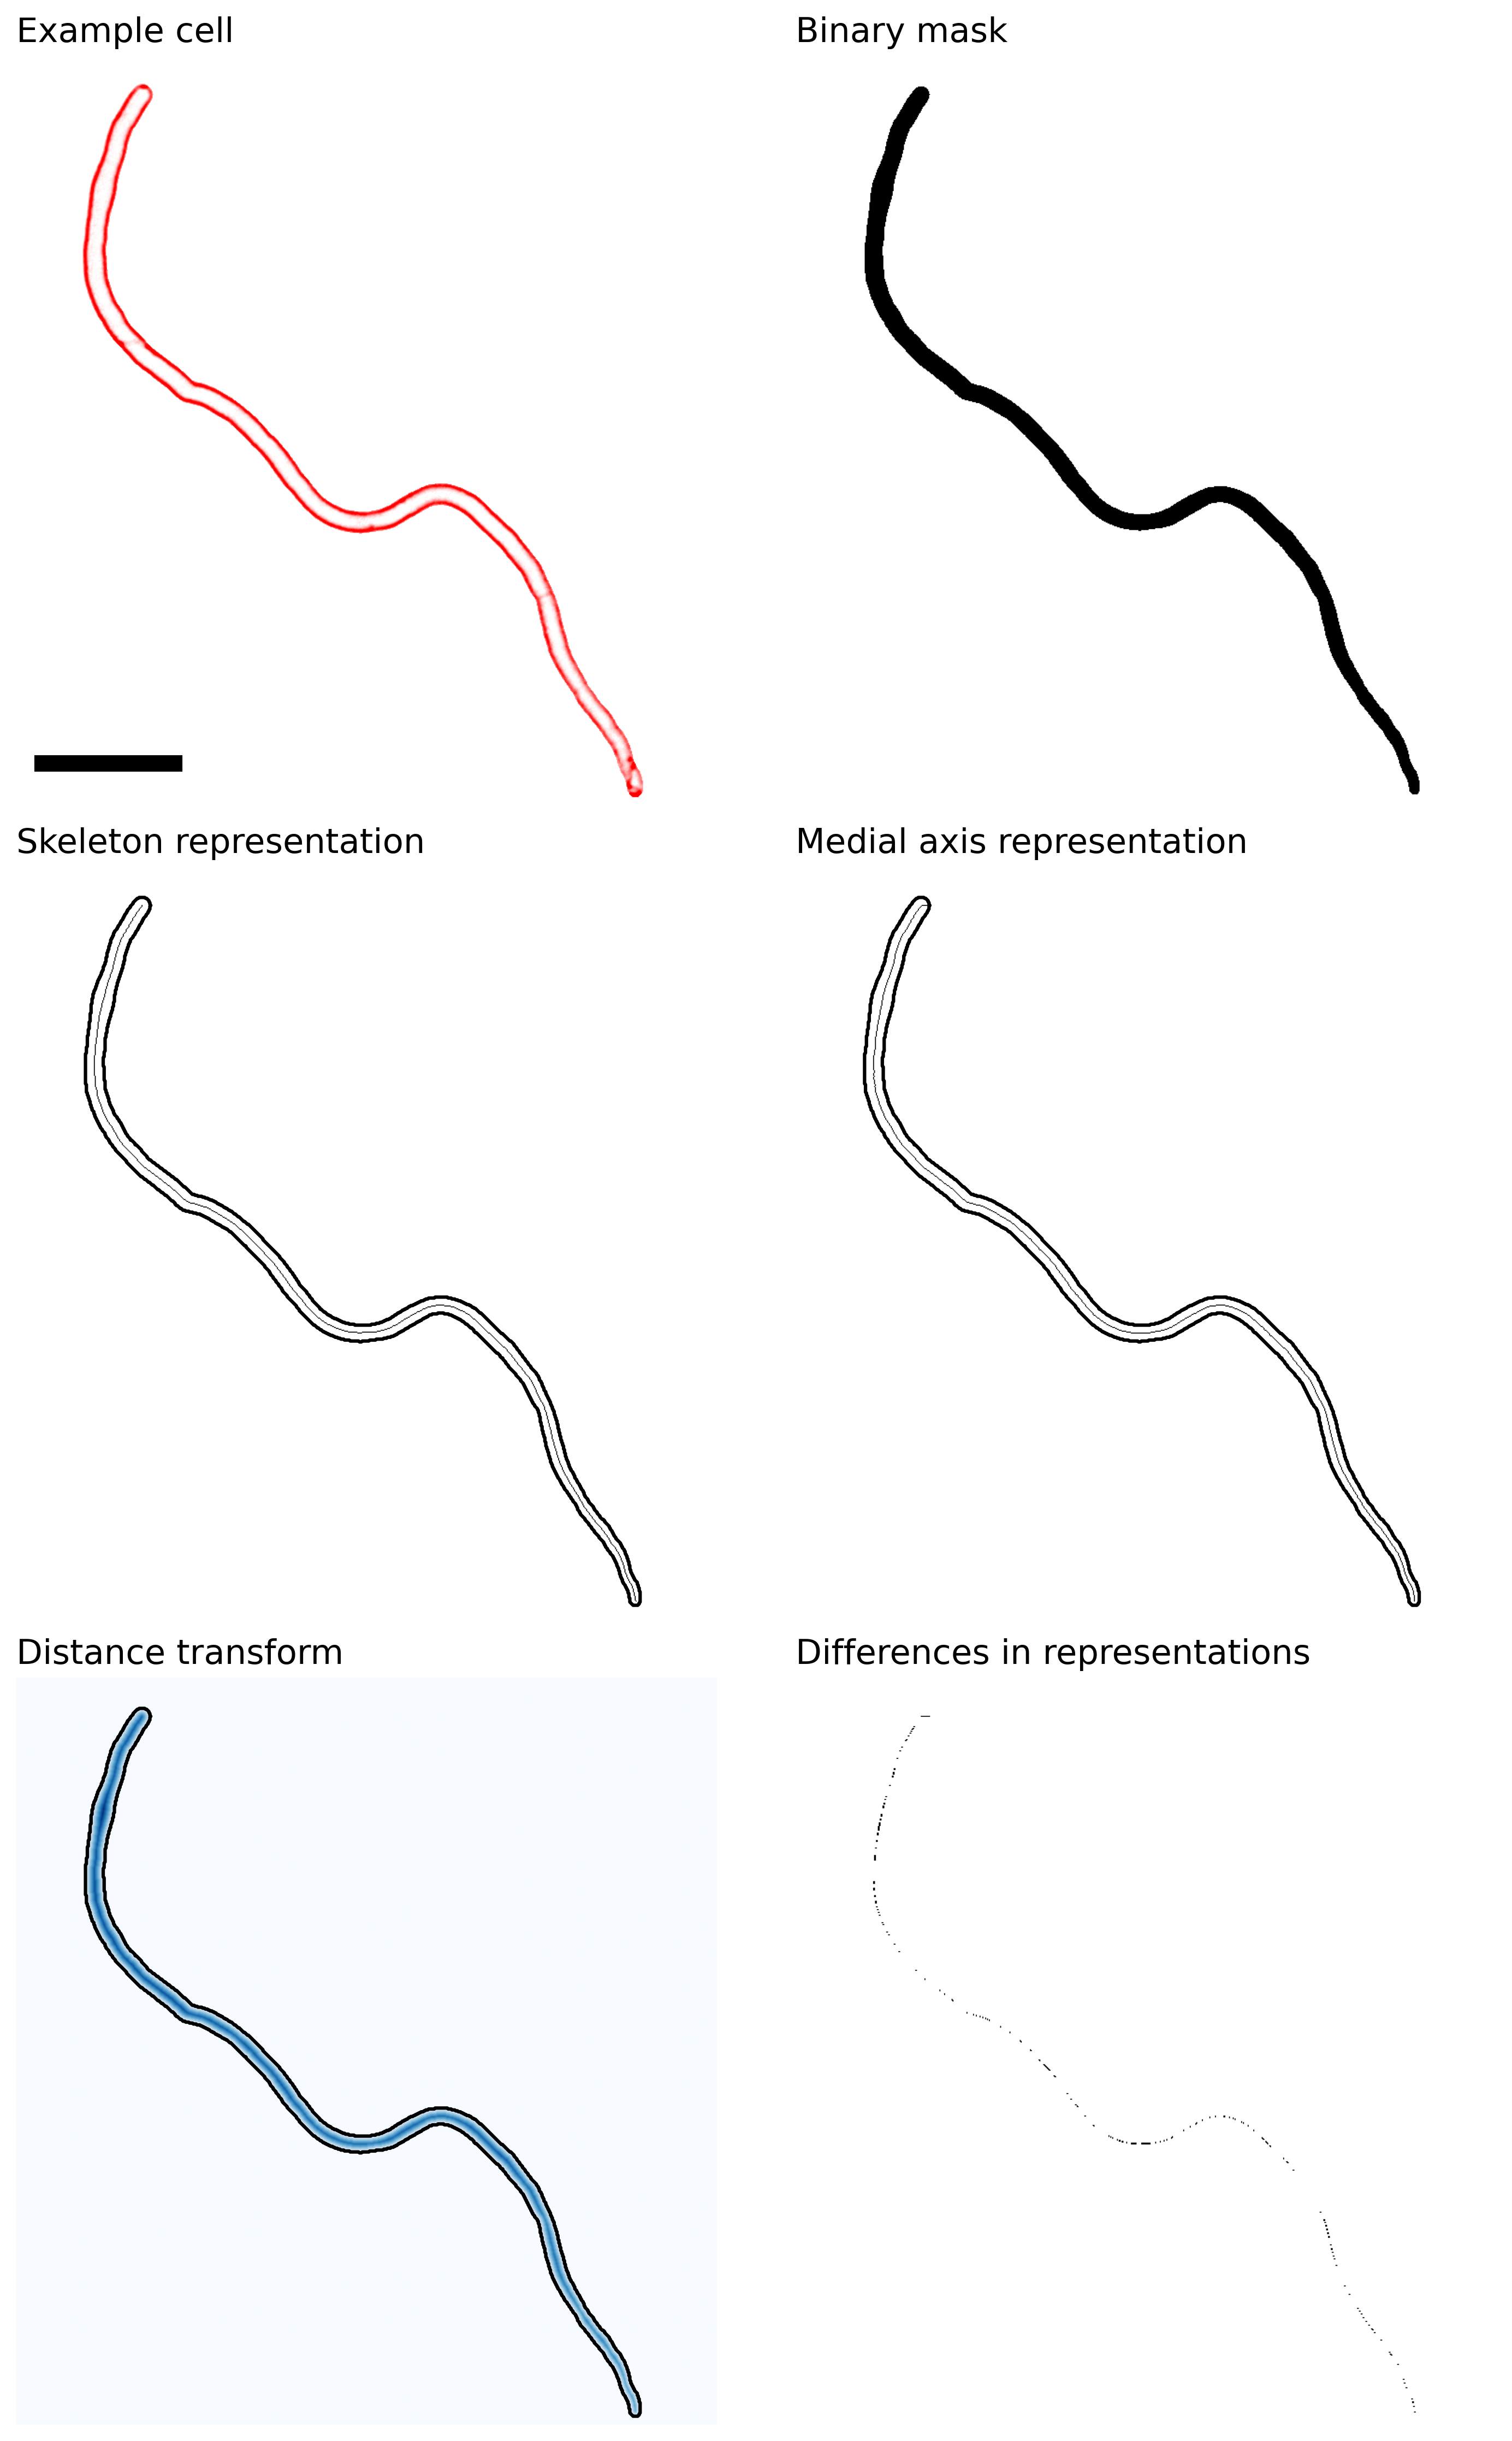

In [76]:
fig,ax = plt.subplots(dpi=300,figsize=(10,15),nrows=3,ncols=2)
cmap = mpl.colors.LinearSegmentedColormap.from_list("", ["white","red"])
patch = patches.Rectangle((20, 750), 156, 15, linewidth=1, edgecolor='black', facecolor='black')

ax[0,0].imshow(cell,cmap=cmap,vmax=3000,vmin=500)
ax[0,0].add_patch(patch)
ax[0,0].set_title('Example cell',loc='left',fontsize=15)
ax[0,0].axis('off')

ax[0,1].imshow(img_,cmap='Greys')
ax[0,1].set_title('Binary mask',loc='left',fontsize=15)
ax[0,1].axis('off')

ax[1,0].contour(img_,cmap='Greys_r')
ax[1,0].imshow(skel,cmap='Greys')
ax[1,0].set_title('Skeleton representation',loc='left',fontsize=15)
ax[1,0].axis('off')

ax[1,1].contour(img_,cmap='Greys_r')
ax[1,1].imshow(medax,cmap='Greys')
ax[1,1].set_title('Medial axis representation',loc='left',fontsize=15)
ax[1,1].axis('off')

ax[2,0].contour(img_,cmap='Greys_r')
ax[2,0].imshow(cellDist,cmap='Blues')
ax[2,0].set_title('Distance transform',loc='left',fontsize=15)
ax[2,0].axis('off')

ax[2,1].imshow(skel^medax,cmap='Greys')
ax[2,1].set_title('Differences in representations',loc='left',fontsize=15)
ax[2,1].axis('off')

fig.tight_layout()
fig.savefig("/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS15/Measuring_mask_example.png")

In [77]:
metrics_skel = SkeletonMeasure(skel,cellDist)
metrics_medax = SkeletonMeasure(medax,cellDist)

## Obtain summary statistics for cell width
w_stats_skel = [metrics_skel[1].max(),metrics_skel[1].mean(),
                np.median(metrics_skel[1]),mode(metrics_skel[1])[0],
                metrics_skel[1].min(),metrics_skel[1].std(),
                metrics_skel[-2],metrics_skel[-1]]
w_stats_skel = [np.round(stat,5) for stat in w_stats_skel]

w_stats_medax = [metrics_medax[1].max(),metrics_medax[1].mean(),
                np.median(metrics_medax[1]),mode(metrics_medax[1])[0],
                metrics_medax[1].min(),metrics_medax[1].std(),
                metrics_medax[-2],metrics_medax[-1]]
w_stats_medax = [np.round(stat,5) for stat in w_stats_medax]


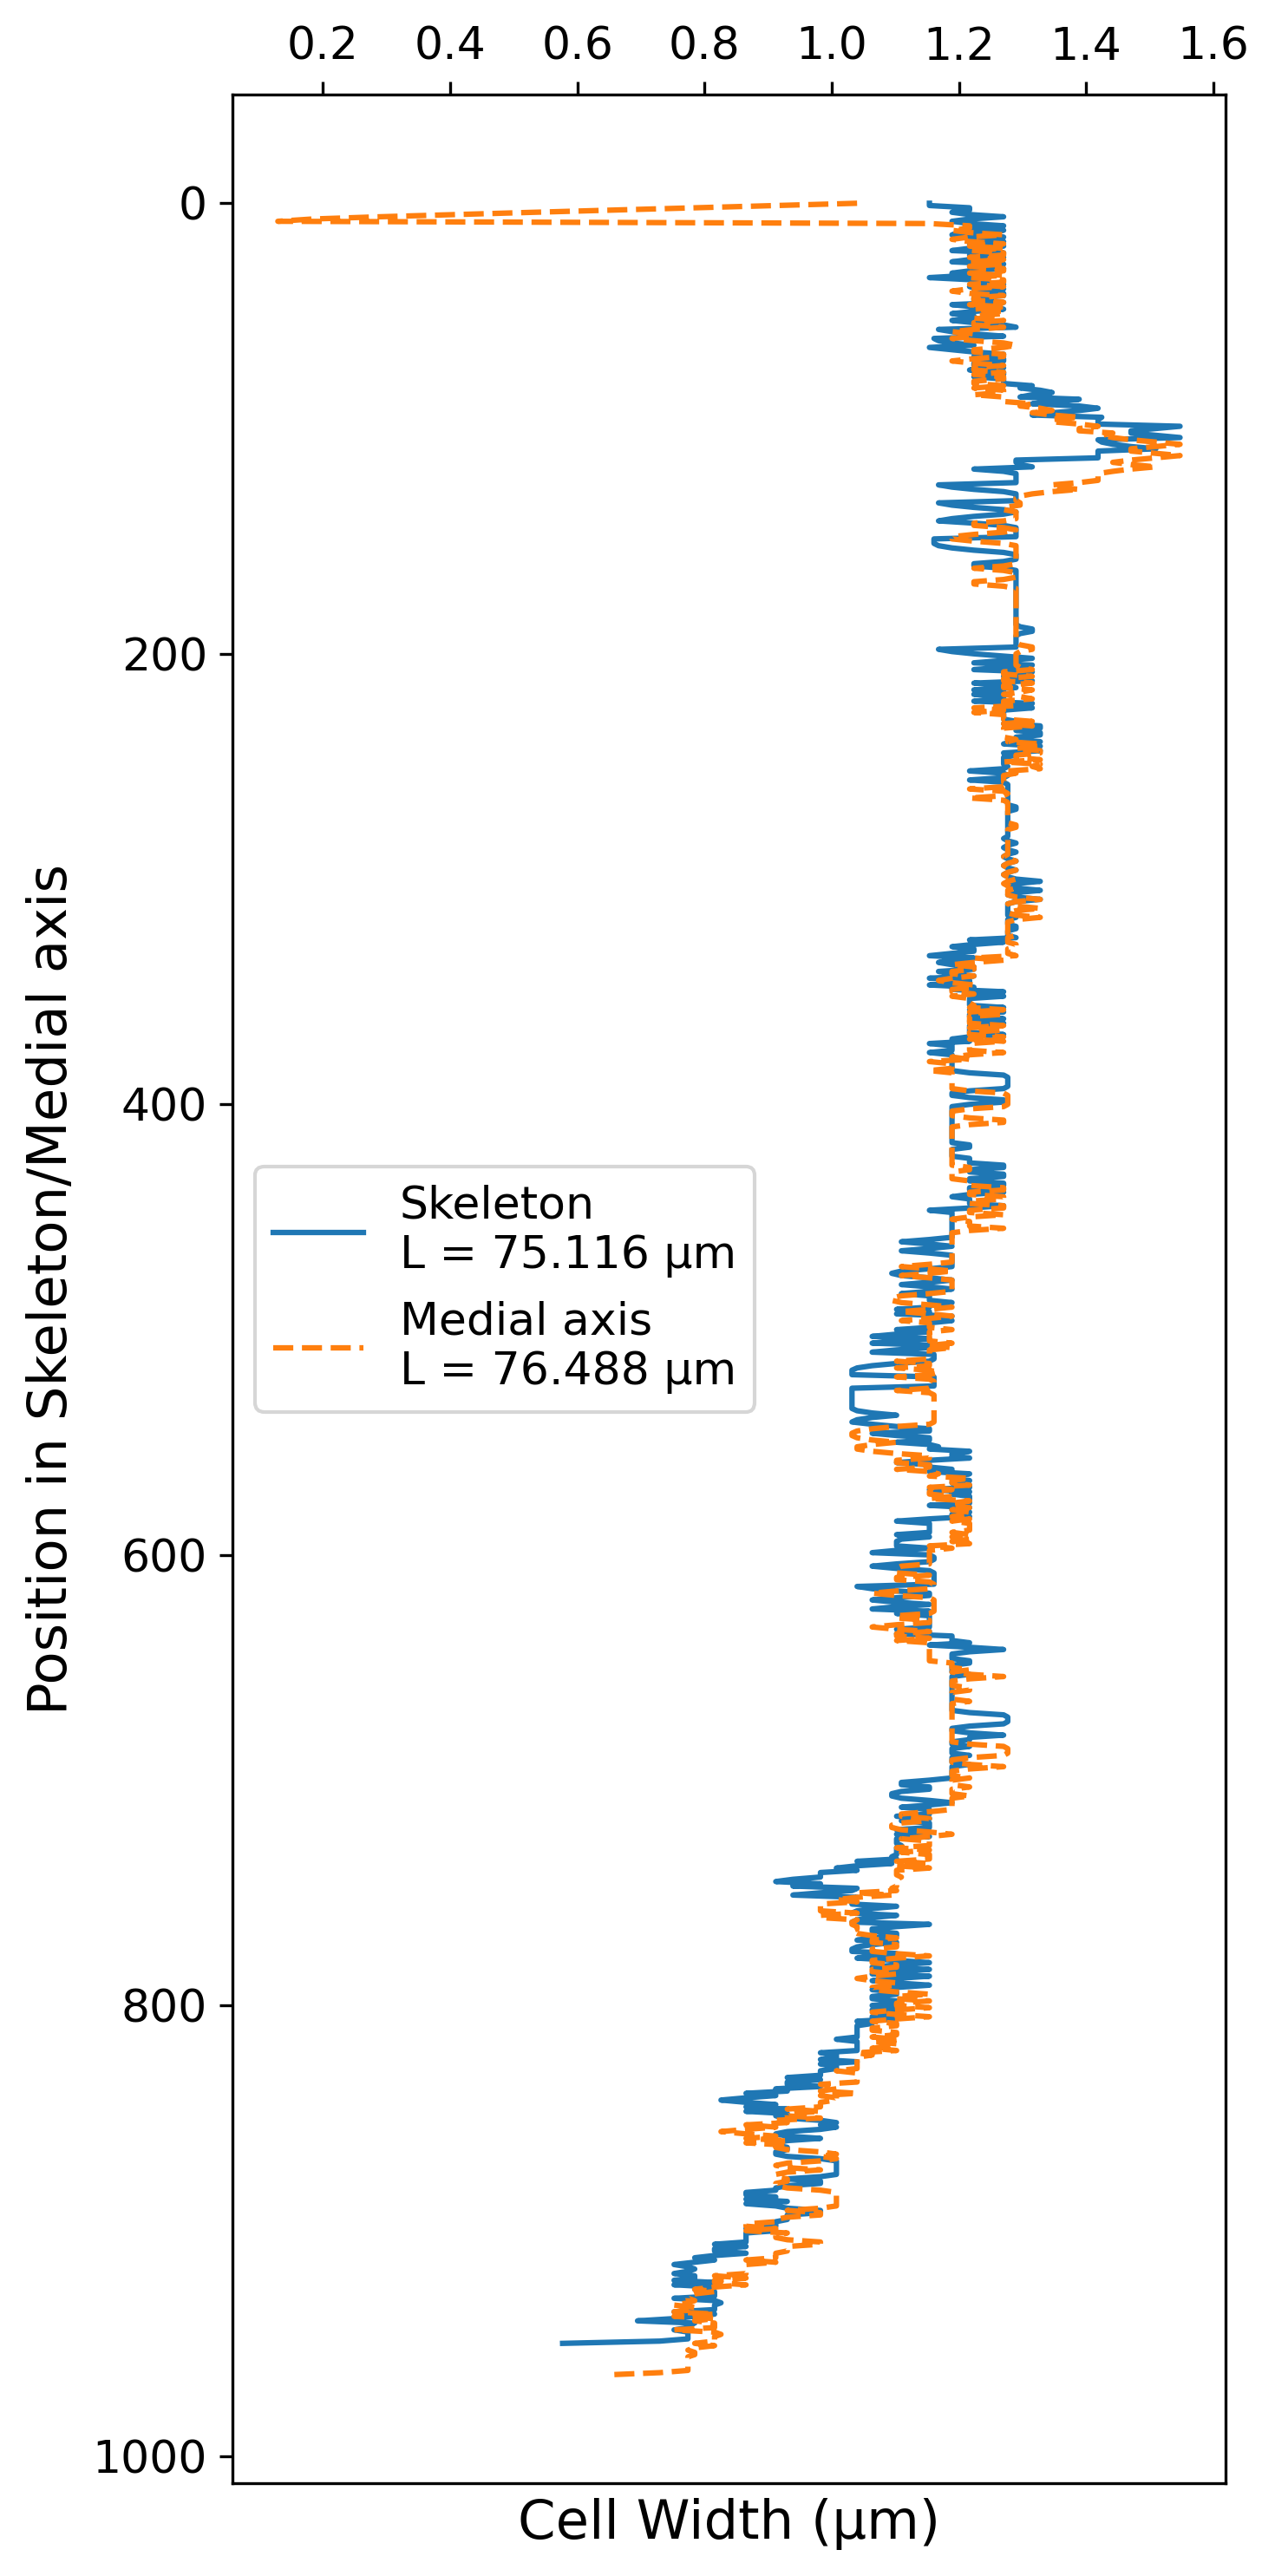

In [109]:
fig,ax = plt.subplots(dpi=300,figsize=(5,10))

ax.plot(metrics_skel[1],[i for i in range(len(metrics_skel[1]))],label=f'Skeleton\nL = {metrics_skel[0]:.3f} µm',linestyle='-')
ax.plot(metrics_medax[1],[i for i in range(len(metrics_medax[1]))],label=f'Medial axis\nL = {metrics_medax[0]:.3f} µm',linestyle='--')
ax.set_xlabel('Cell Width (µm)',fontsize=15)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=12.5)
ax.legend(fontsize=12.5,loc='center left')
ax.set_xticklabels(ax.get_xticklabels(),fontsize=12.5)
ax.xaxis.tick_top()
ax.set_ylabel('Position in Skeleton/Medial axis',fontsize=15)
ax.yaxis.set_inverted(True)


fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS15/Cell_width_skeleton.png')

### Compare skeletons and medial axes for multiple cells (use the ground-truths of figure S8)

In [4]:
### Get the sample list
!wget = 'https://ftp.ebi.ac.uk/pub/databases/biostudies/S-BIAD/352/S-BIAD2352/Files/submission_Ecoli_FMSeg.tsv'

samples = pd.read_table('submission_Ecoli_FMSeg.tsv')

## Get the cell IDs
cells = np.array(samples['Files'])
cells = [cell.split('/')[-1].split('.')[0] for cell in cells]

### Read the cells directly from the repository
GT_cells_path = 'https://ftp.ebi.ac.uk/pub/databases/biostudies/S-BIAD/352/S-BIAD2352/Files/Ecoli_segmentation/JFilament/'

gt_masks = [binary_fill_holes(io.imread(f'{GT_cells_path}{cell}.tif')) > 0 for cell in cells]

--2026-03-13 11:26:38--  http://=/
Resolving = (=)... failed: nodename nor servname provided, or not known.
wget: unable to resolve host address ‘=’
--2026-03-13 11:26:38--  https://ftp.ebi.ac.uk/pub/databases/biostudies/S-BIAD/352/S-BIAD2352/Files/submission_Ecoli_FMSeg.tsv
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 132112 (129K) [text/tab-separated-values]
Saving to: ‘submission_Ecoli_FMSeg.tsv.7’

submission_Ecoli_FM 100%[===================>] 129,02K  --.-KB/s    in 0,06s   

2026-03-13 11:26:38 (2,04 MB/s) - ‘submission_Ecoli_FMSeg.tsv.7’ saved [132112/132112]

FINISHED --2026-03-13 11:26:38--
Total wall clock time: 0,4s
Downloaded: 1 files, 129K in 0,06s (2,04 MB/s)


In [6]:
gt_masks = [np.uint8(mask) for mask in gt_masks]

In [27]:
df_skel = SizeDataFrame(gt_masks,from_files=False)
df_skel.insert(0,'Representation','Skeleton')

df_medax = SizeDataFrameMedax(gt_masks,from_files=False)
df_medax.insert(0,'Representation','Medial axis')

In [28]:
df_skel.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS15_skeleton_measures.csv')
df_medax.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS15_medialaxis_measures.csv')

In [36]:
names = ['Length', 'Width', 'SurfaceArea', 'Volume']
ylabs = ['Cell Length (µm)','Cell Width (µm)','Cell Surface Area (µm$^2$)','Cell Volume (µm$^3$)']

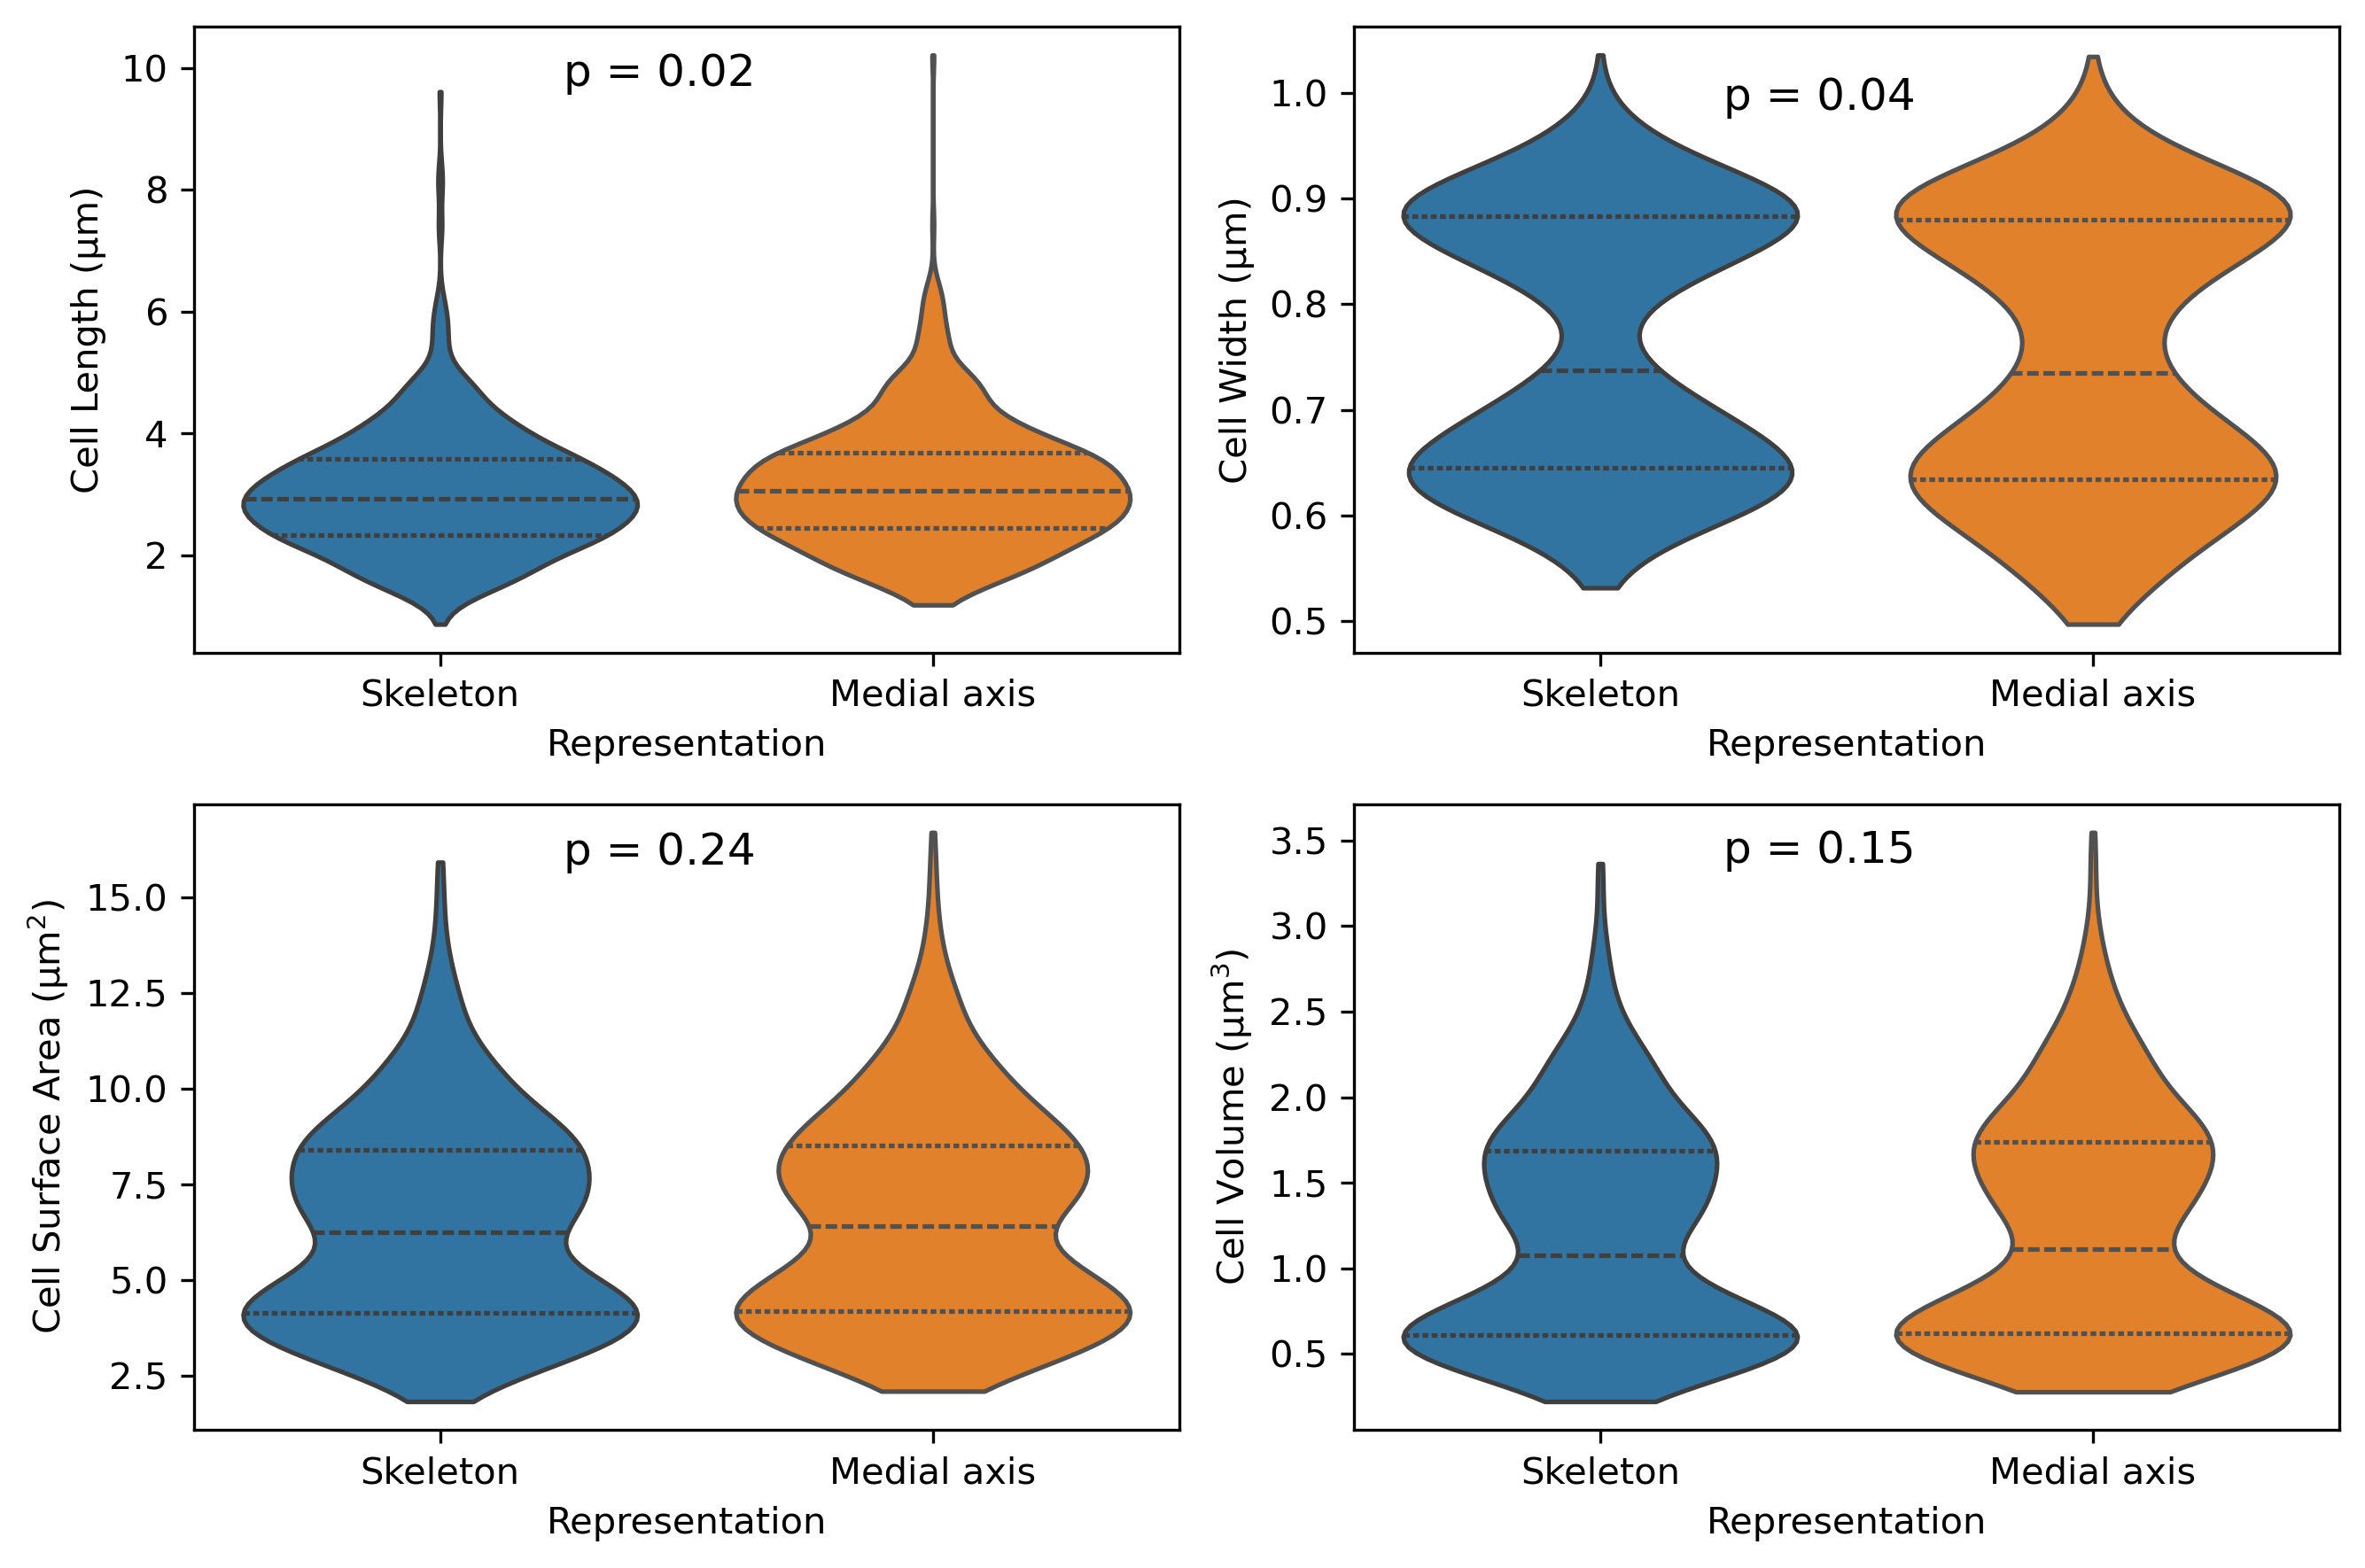

In [41]:
df_skel = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS15_skeleton_measures.csv')
df_medax = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS15_medialaxis_measures.csv')

fig,ax = plt.subplots(dpi=300,figsize=(9,6),ncols=2,nrows=2)
ax=ax.flatten()
for i in range(len(names)):

    m1 = np.array(df_skel[names[i]])
    m1 = m1[~np.isnan(m1)]
    
    m2 = np.array(df_medax[names[i]])
    m2 = m2[~np.isnan(m2)]

    p_lev = levene(m1,m2)[1]

    if p_lev > 0.05:

        p = f_oneway(m1,m2)[1]

        pval = f'p = {p:.2f}'
        
        if p < 0.0001: pval = 'p < 0.01'
        
    else:

        p = kruskal(m1,m2)[1]

        pval = f'p = {p:.2f}'

        if p < 0.01: pval = 'p < 0.01'

    sns.violinplot(x=0,y=m1,ax=ax[i],inner='quart',cut=0)
    sns.violinplot(x=1,y=m2,ax=ax[i],inner='quart',cut=0)
    ax[i].text(0.25,np.concat([m1,m2]).max()*0.95,pval,fontsize=12)
    ax[i].set_xticklabels(['Skeleton','Medial axis'])
    ax[i].set_xlabel('Representation')
    ax[i].set_ylabel(ylabs[i])

fig.tight_layout()
fig.savefig(f'/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS15/Violins_representation.png')